In [2]:
print("My Titanic notebook is working!")
print("Python is ready!")

My Titanic notebook is working!
Python is ready!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
Pandas version: 3.0.3


In [4]:
# Load the dataset
df = pd.read_csv('../data/Titanic-Dataset.csv')

# Check if loaded properly
print(f"✅ Dataset loaded successfully!")
print(f"Total passengers: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

✅ Dataset loaded successfully!
Total passengers: 891
Total columns: 12

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            11

In [5]:
# Get detailed info about the dataset
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
print(df.describe())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

DESCRIPTIVE STATISTICS
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   


In [6]:
# Check missing values
print("=" * 50)
print("MISSING VALUES ANALYSIS")
print("=" * 50)

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

MISSING VALUES ANALYSIS
          Missing Count  Percentage
Age                 177   19.865320
Cabin               687   77.104377
Embarked              2    0.224467


C:\Users\shrey\AppData\Local\Temp\ipykernel_9520\3492234342.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0,0].set_xticklabels(['Died', 'Survived'])


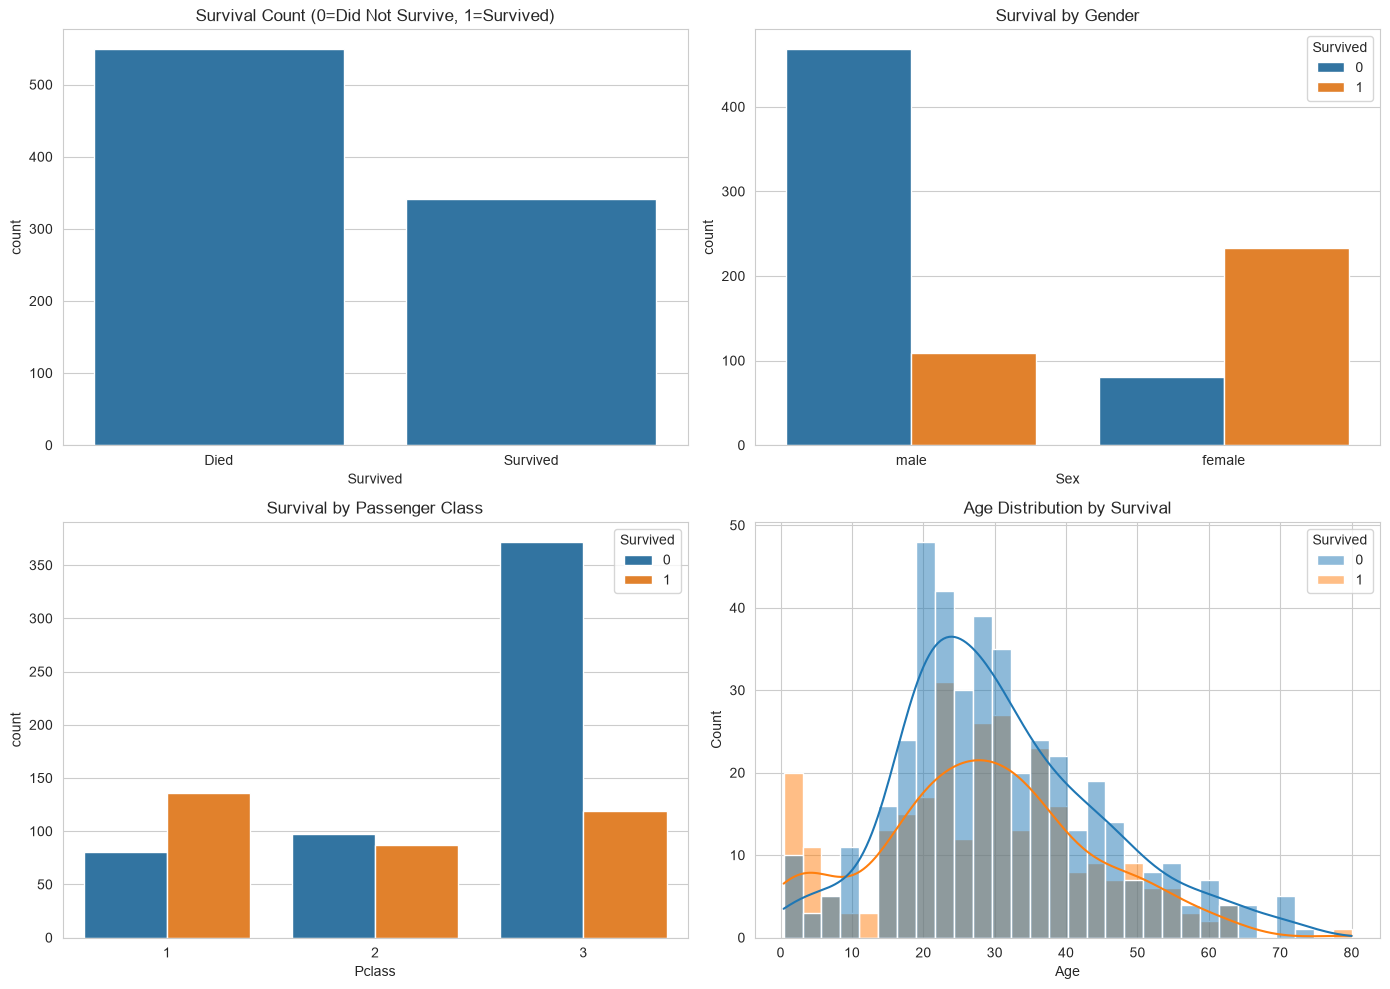

In [7]:
# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create a figure with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival count
sns.countplot(data=df, x='Survived', ax=axes[0,0])
axes[0,0].set_title('Survival Count (0=Did Not Survive, 1=Survived)')
axes[0,0].set_xticklabels(['Died', 'Survived'])

# 2. Survival by Gender
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

# 3. Survival by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1,0])
axes[1,0].set_title('Survival by Passenger Class')

# 4. Age distribution
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

In [8]:
# Complete data cleaning - FIXED VERSION
df_clean = df.copy()

print("Before cleaning:")
print(f"Missing values per column:\n{df_clean.isnull().sum()}")

# Fill missing Age with median
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Fill missing Embarked with mode (most frequent)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Fill missing Fare with median (if any)
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# Drop Cabin column (too many missing values - over 70% missing)
df_clean = df_clean.drop('Cabin', axis=1)

# Drop other non-useful columns
df_clean = df_clean.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

print("\nAfter cleaning:")
print(f"Missing values per column:\n{df_clean.isnull().sum()}")
print(f"\nDataset shape: {df_clean.shape}")
print(f"\nFirst 5 rows:")
print(df_clean.head())

Before cleaning:
Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After cleaning:
Missing values per column:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Dataset shape: (891, 8)

First 5 rows:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode Sex
le_sex = LabelEncoder()
df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])

# Encode Embarked
le_embarked = LabelEncoder()
df_clean['Embarked'] = le_embarked.fit_transform(df_clean['Embarked'])

print("After encoding:")
print(df_clean.head())
print(f"\nData types:\n{df_clean.dtypes}")

After encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2

Data types:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# VERIFY: Check if any NaN still exist
print(f"NaN in X before split: {X.isnull().sum().sum()}")
print(f"NaN in y before split: {y.isnull().sum()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# VERIFY: Check for NaN after scaling (should be 0)
print(f"\nNaN in X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print(f"NaN in X_test_scaled: {np.isnan(X_test_scaled).sum()}")

print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")
print(f"Features: {list(X.columns)}")

NaN in X before split: 0
NaN in y before split: 0

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0

Training set shape: (712, 7)
Testing set shape: (179, 7)
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.7989
Accuracy Percentage: 79.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[97 13]
 [23 46]]


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Try different models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:15} Accuracy: {acc:.4f}")

Random Forest   Accuracy: 0.8268
Decision Tree   Accuracy: 0.8324
SVM             Accuracy: 0.8156


In [13]:
# Complete Feature Engineering
import pandas as pd
import numpy as np

# 1. Extract titles from names
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 3. Create is_alone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 4. Create age groups (binning)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# 5. Create fare groups
df['FareGroup'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Display results
print("✅ Feature engineering completed!")
print(f"\nDataset now has {df.shape[1]} columns (was {df.shape[1]-5} before)")
print("\nNew features added:")
print(f"- Title: {df['Title'].nunique()} unique values")
print(f"- FamilySize: ranges from {df['FamilySize'].min()} to {df['FamilySize'].max()}")
print(f"- IsAlone: {df['IsAlone'].sum()} passengers are alone")
print(f"- AgeGroup: {df['AgeGroup'].nunique()} groups")
print(f"- FareGroup: {df['FareGroup'].nunique()} groups")

print("\nSample of data with new features:")
print(df[['Name', 'Title', 'Age', 'AgeGroup', 'Fare', 'FareGroup', 'FamilySize', 'IsAlone']].head())
from sklearn.preprocessing import LabelEncoder

# Encode Title
le_title = LabelEncoder()
df['Title'] = le_title.fit_transform(df['Title'])

# Encode AgeGroup
le_age = LabelEncoder()
df['AgeGroup'] = le_age.fit_transform(df['AgeGroup'])

# Encode FareGroup
le_fare = LabelEncoder()
df['FareGroup'] = le_fare.fit_transform(df['FareGroup'])

print("✅ New features encoded!")
print(f"Title mapping: {dict(zip(le_title.classes_, range(len(le_title.classes_))))}")

✅ Feature engineering completed!

Dataset now has 17 columns (was 12 before)

New features added:
- Title: 17 unique values
- FamilySize: ranges from 1 to 11
- IsAlone: 537 passengers are alone
- AgeGroup: 5 groups
- FareGroup: 4 groups

Sample of data with new features:
                                                Name Title   Age     AgeGroup  \
0                            Braund, Mr. Owen Harris    Mr  22.0  Young Adult   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs  38.0        Adult   
2                             Heikkinen, Miss. Laina  Miss  26.0  Young Adult   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs  35.0  Young Adult   
4                           Allen, Mr. William Henry    Mr  35.0  Young Adult   

      Fare  FareGroup  FamilySize  IsAlone  
0   7.2500        Low           2        0  
1  71.2833  Very High           2        0  
2   7.9250     Medium           1        1  
3  53.1000  Very High           2        0  
4   8.0500     M

In [14]:
# Check for missing titles
print(f"Missing titles: {df['Title'].isnull().sum()}")

# Fill missing titles with 'Unknown'
df['Title'] = df['Title'].fillna('Unknown')

# Encode again after filling
df['Title'] = LabelEncoder().fit_transform(df['Title'])

print("✅ Missing titles handled!")

Missing titles: 0
✅ Missing titles handled!


In [15]:
# COMPLETE FEATURE ENGINEERING - NO WARNINGS
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying original
df_fe = df.copy()

# 1. Extract titles (USING RAW STRING r'...')
df_fe['Title'] = df_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 2. Fill missing titles
df_fe['Title'] = df_fe['Title'].fillna('Unknown')

# 3. Create family features
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)

# 4. Create age groups
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# 5. Create fare groups
df_fe['FareGroup'] = pd.qcut(df_fe['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# 6. Encode categorical features
le_title = LabelEncoder()
df_fe['Title'] = le_title.fit_transform(df_fe['Title'])

le_age = LabelEncoder()
df_fe['AgeGroup'] = le_age.fit_transform(df_fe['AgeGroup'])

le_fare = LabelEncoder()
df_fe['FareGroup'] = le_fare.fit_transform(df_fe['FareGroup'])

print("✅ All features engineered and encoded!")
print(f"\nNew dataset shape: {df_fe.shape}")
print(f"\nFeatures available:")
for col in df_fe.columns:
    print(f"  - {col}")

# Show sample
print("\nSample of engineered data:")
print(df_fe[['Pclass', 'Sex', 'Age', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup', 'Survived']].head(10))


✅ All features engineered and encoded!

New dataset shape: (891, 17)

Features available:
  - PassengerId
  - Survived
  - Pclass
  - Name
  - Sex
  - Age
  - SibSp
  - Parch
  - Ticket
  - Fare
  - Cabin
  - Embarked
  - Title
  - FamilySize
  - IsAlone
  - AgeGroup
  - FareGroup

Sample of engineered data:
   Pclass     Sex   Age  Title  FamilySize  IsAlone  AgeGroup  FareGroup  \
0       3    male  22.0     12           2        0         4          1   
1       1  female  38.0     13           2        0         0          3   
2       3  female  26.0      9           1        1         4          2   
3       1  female  35.0     13           2        0         4          3   
4       3    male  35.0     12           1        1         4          2   
5       3    male   NaN     12           1        1         5          2   
6       1    male  54.0     12           1        1         0          3   
7       3    male   2.0      8           5        0         1          0   
8     

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [19]:
# Load the dataset
df = pd.read_csv('../data/Titanic-Dataset.csv')

print(f"✅ Dataset loaded successfully!")
print(f"Total passengers: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

✅ Dataset loaded successfully!
Total passengers: 891
Total columns: 12

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            11

In [20]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(df.describe())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

MISSING VALUES
          Missing Count  Percentage
Age                 177   19.865320
Cabin               687   77.104377
Embarked              2    0.224467

BASIC STATISTICS
       PassengerId    Survived      Pclass         Age  

In [21]:
# Create a copy for cleaning
df_clean = df.copy()

print("Before cleaning:")
print(f"Missing values total: {df_clean.isnull().sum().sum()}")

# Fill missing Age with median
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Fill missing Embarked with mode (most frequent)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Fill missing Fare with median
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# Drop columns with too many missing values or not useful
df_clean = df_clean.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print("\nAfter cleaning:")
print(f"Missing values total: {df_clean.isnull().sum().sum()}")
print(f"Dataset shape: {df_clean.shape}")
print(f"\nFirst 5 rows:")
print(df_clean.head())

Before cleaning:
Missing values total: 866

After cleaning:
Missing values total: 0
Dataset shape: (891, 8)

First 5 rows:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [22]:
# Create a copy for feature engineering
df_fe = df_clean.copy()

# 1. Extract titles from names (using raw string r'...' to avoid warning)
df_fe['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 2. Fill missing titles
df_fe['Title'] = df_fe['Title'].fillna('Unknown')

# 3. Create family size feature
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1

# 4. Create is_alone feature
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)

# 5. Create age groups
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[0, 12, 18, 35, 60, 100], 
                           labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# 6. Create fare groups
df_fe['FareGroup'] = pd.qcut(df_fe['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

print("✅ Feature engineering completed!")
print(f"\nNew features added: Title, FamilySize, IsAlone, AgeGroup, FareGroup")
print(f"Dataset now has {df_fe.shape[1]} columns (was {df_fe.shape[1]-5})")
print(f"\nSample of new features:")
print(df_fe[['Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']].head(10))

✅ Feature engineering completed!

New features added: Title, FamilySize, IsAlone, AgeGroup, FareGroup
Dataset now has 13 columns (was 8)

Sample of new features:
    Title  FamilySize  IsAlone     AgeGroup  FareGroup
0      Mr           2        0  Young Adult        Low
1     Mrs           2        0        Adult  Very High
2    Miss           1        1  Young Adult     Medium
3     Mrs           2        0  Young Adult  Very High
4      Mr           1        1  Young Adult     Medium
5      Mr           1        1  Young Adult     Medium
6      Mr           1        1        Adult  Very High
7  Master           5        0        Child       High
8     Mrs           3        0  Young Adult     Medium
9     Mrs           2        0         Teen       High


In [23]:
# Encode all categorical features
le_sex = LabelEncoder()
df_fe['Sex'] = le_sex.fit_transform(df_fe['Sex'])

le_embarked = LabelEncoder()
df_fe['Embarked'] = le_embarked.fit_transform(df_fe['Embarked'])

le_title = LabelEncoder()
df_fe['Title'] = le_title.fit_transform(df_fe['Title'])

le_agegroup = LabelEncoder()
df_fe['AgeGroup'] = le_agegroup.fit_transform(df_fe['AgeGroup'])

le_faregroup = LabelEncoder()
df_fe['FareGroup'] = le_faregroup.fit_transform(df_fe['FareGroup'])

print("✅ All categorical features encoded!")
print(f"\nEncoding mappings:")
print(f"  Sex: 0=Female, 1=Male")
print(f"  Embarked: 0=C, 1=Q, 2=S")
print(f"  Title: {dict(zip(le_title.classes_, range(len(le_title.classes_))))}")
print(f"  AgeGroup: {dict(zip(le_agegroup.classes_, range(len(le_agegroup.classes_))))}")
print(f"  FareGroup: {dict(zip(le_faregroup.classes_, range(len(le_faregroup.classes_))))}")

print(f"\nFirst 5 rows after encoding:")
print(df_fe.head())

✅ All categorical features encoded!

Encoding mappings:
  Sex: 0=Female, 1=Male
  Embarked: 0=C, 1=Q, 2=S
  Title: {'Capt': 0, 'Col': 1, 'Countess': 2, 'Don': 3, 'Dr': 4, 'Jonkheer': 5, 'Lady': 6, 'Major': 7, 'Master': 8, 'Miss': 9, 'Mlle': 10, 'Mme': 11, 'Mr': 12, 'Mrs': 13, 'Ms': 14, 'Rev': 15, 'Sir': 16}
  AgeGroup: {'Adult': 0, 'Child': 1, 'Senior': 2, 'Teen': 3, 'Young Adult': 4}
  FareGroup: {'High': 0, 'Low': 1, 'Medium': 2, 'Very High': 3}

First 5 rows after encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
0         0       3    1  22.0      1      0   7.2500         2     12   
1         1       1    0  38.0      1      0  71.2833         0     13   
2         1       3    0  26.0      0      0   7.9250         2      9   
3         1       1    0  35.0      1      0  53.1000         2     13   
4         0       3    1  35.0      0      0   8.0500         2     12   

   FamilySize  IsAlone  AgeGroup  FareGroup  
0           2        0     

In [10]:
# Select features for training (including new ones)
feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
                   'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']

X = df_fe[feature_columns]
y = df_fe['Survived']

# Check for any remaining missing values
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Data prepared!")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")
print(f"Features used ({len(feature_columns)}): {feature_columns}")

Missing values in X: 0
Missing values in y: 0

✅ Data prepared!
Training set shape: (712, 12)
Testing set shape: (179, 12)
Features used (12): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']


In [32]:
# Initialize different models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (Tuned)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
}

print("=" * 60)
print("TRAINING MODELS WITH ENGINEERED FEATURES")
print("=" * 60)

results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    
    # Print results
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

print("\n" + "=" * 60)

# Find and display best model
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['Accuracy']:.4f} ({results[best_model_name]['Accuracy']*100:.2f}%)")

TRAINING MODELS WITH ENGINEERED FEATURES

Logistic Regression:
  Accuracy:  0.7989 (79.89%)
  Precision: 0.7797
  Recall:    0.6667
  F1-Score:  0.7188

Decision Tree:
  Accuracy:  0.8324 (83.24%)
  Precision: 0.8000
  Recall:    0.7536
  F1-Score:  0.7761

Random Forest:
  Accuracy:  0.8268 (82.68%)
  Precision: 0.8065
  Recall:    0.7246
  F1-Score:  0.7634

Random Forest (Tuned):
  Accuracy:  0.7989 (79.89%)
  Precision: 0.7797
  Recall:    0.6667
  F1-Score:  0.7188


🏆 BEST MODEL: Decision Tree
   Accuracy: 0.8324 (83.24%)


In [33]:
# Use the best Random Forest model to analyze feature importance
rf_best = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_best.fit(X_train_scaled, y_train)

# Get feature importance
importances = rf_best.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)
print(feature_importance_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(importances / max(importances))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance for Survival Prediction', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📊 Top 3 Most Important Features:")
for i in range(3):
    print(f"  {i+1}. {feature_importance_df.iloc[i]['Feature']}: {feature_importance_df.iloc[i]['Importance']:.4f}")

NameError: name 'feature_columns' is not defined

In [28]:
# Use the best Random Forest model to analyze feature importance
rf_best = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_best.fit(X_train_scaled, y_train)

# Get feature importance
importances = rf_best.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)
print(feature_importance_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(importances / max(importances))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance for Survival Prediction', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📊 Top 3 Most Important Features:")
for i in range(3):
    print(f"  {i+1}. {feature_importance_df.iloc[i]['Feature']}: {feature_importance_df.iloc[i]['Importance']:.4f}")

NameError: name 'feature_columns' is not defined

In [30]:
import joblib

# Save the best model and scaler
best_model = models[best_model_name]
joblib.dump(best_model, '../models/titanic_best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print(f"✅ Model saved as 'titanic_best_model.pkl'")
print(f"✅ Scaler saved as 'scaler.pkl'")
print(f"\nYou can now load and use this model for predictions!")

✅ Model saved as 'titanic_best_model.pkl'
✅ Scaler saved as 'scaler.pkl'

You can now load and use this model for predictions!


In [46]:
# Try Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb_model.predict(X_test_scaled)):.4f}")

Gradient Boosting Accuracy: 0.8101


In [29]:
# Confusion Matrix Visualization
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, 
                                       display_labels=['Died', 'Survived'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

NameError: name 'best_model' is not defined

In [48]:
def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    # Create DataFrame with all required features
    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [0 if sex.lower() == 'female' else 1],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Embarked': [{'C':0, 'Q':1, 'S':2}[embarked.upper()]],
        'Title': [1],  # Default title encoding
        'FamilySize': [sibsp + parch + 1],
        'IsAlone': [1 if (sibsp + parch) == 0 else 0],
        'AgeGroup': [2],  # Default adult
        'FareGroup': [2]   # Default medium
    })
    
    # Scale and predict
    passenger_scaled = scaler.transform(passenger)
    pred = best_model.predict(passenger_scaled)[0]
    prob = best_model.predict_proba(passenger_scaled)[0][1]
    
    return "Survived" if pred == 1 else "Did not survive", f"{prob*100:.1f}% chance"

# Test examples
print("Test predictions:")
print(f"Young female, 1st class: {predict_survival(1, 'female', 25, 0, 0, 100, 'C')}")
print(f"Elderly male, 3rd class: {predict_survival(3, 'male', 70, 0, 0, 10, 'S')}")

Test predictions:
Young female, 1st class: ('Survived', '97.6% chance')
Elderly male, 3rd class: ('Did not survive', '4.1% chance')


In [49]:
# Create a summary DataFrame
summary_df = pd.DataFrame(results).T
summary_df.to_csv('../models/model_comparison.csv')
print("✅ Results exported to 'model_comparison.csv'")

✅ Results exported to 'model_comparison.csv'


In [50]:
# Create a test function
def test_passenger(pclass, sex, age, sibsp, parch, fare, embarked):
    """
    Test survival prediction for a single passenger
    """
    # Calculate derived features
    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0
    
    # Determine title based on sex and age (simplified)
    if sex.lower() == 'female':
        if age < 18:
            title = 'Miss'  # Will be encoded
        else:
            title = 'Mrs'
    else:
        if age < 18:
            title = 'Master'
        else:
            title = 'Mr'
    
    # Map title to number (based on your encoding)
    title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Unknown': 4}
    title_encoded = title_mapping.get(title, 4)
    
    # Map age group
    if age <= 12:
        age_group = 0  # Child
    elif age <= 18:
        age_group = 1  # Teen
    elif age <= 35:
        age_group = 2  # Young Adult
    elif age <= 60:
        age_group = 3  # Adult
    else:
        age_group = 4  # Senior
    
    # Map fare group
    if fare <= 8.0:
        fare_group = 0  # Low
    elif fare <= 15.0:
        fare_group = 1  # Medium
    elif fare <= 31.0:
        fare_group = 2  # High
    else:
        fare_group = 3  # Very High
    
    # Create passenger dataframe
    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [1 if sex.lower() == 'male' else 0],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Embarked': [{'c':0, 'q':1, 's':2}[embarked.lower()]],
        'Title': [title_encoded],
        'FamilySize': [family_size],
        'IsAlone': [is_alone],
        'AgeGroup': [age_group],
        'FareGroup': [fare_group]
    })
    
    # Scale and predict
    passenger_scaled = scaler.transform(passenger)
    prediction = best_model.predict(passenger_scaled)[0]
    probability = best_model.predict_proba(passenger_scaled)[0][1]
    
    return prediction, probability

# Test with known examples from history
print("=" * 60)
print("TESTING WITH HISTORICAL PASSENGERS")
print("=" * 60)

# Known survivors
test_cases = [
    ("Rose DeWitt Bukater", 1, "female", 17, 0, 0, 100, "C"),  # 1st class young lady
    ("Jack Dawson", 3, "male", 20, 0, 0, 8, "S"),  # 3rd class young man
    ("Margaret Brown", 1, "female", 45, 0, 0, 75, "C"),  # Rich lady
    ("Young Family", 2, "female", 30, 1, 2, 25, "S"),  # Mother with children
]

for name, pclass, sex, age, sibsp, parch, fare, embarked in test_cases:
    pred, prob = test_passenger(pclass, sex, age, sibsp, parch, fare, embarked)
    result = "SURVIVED" if pred == 1 else "DIED"
    print(f"\n{name}:")
    print(f"  Class {pclass}, {sex}, {age} years")
    print(f"  Prediction: {result} ({prob*100:.1f}% chance of survival)")

TESTING WITH HISTORICAL PASSENGERS

Rose DeWitt Bukater:
  Class 1, female, 17 years
  Prediction: SURVIVED (98.4% chance of survival)

Jack Dawson:
  Class 3, male, 20 years
  Prediction: DIED (25.1% chance of survival)

Margaret Brown:
  Class 1, female, 45 years
  Prediction: SURVIVED (93.5% chance of survival)

Young Family:
  Class 2, female, 30 years
  Prediction: SURVIVED (82.1% chance of survival)


In [51]:
# Test various scenarios
scenarios = pd.DataFrame({
    'Scenario': [
        'Rich Young Lady',
        'Poor Young Man', 
        'Middle-aged Mother',
        'Elderly Rich Man',
        'Young Child',
        'Teenage Boy'
    ],
    'Pclass': [1, 3, 2, 1, 1, 2],
    'Sex': ['female', 'male', 'female', 'male', 'female', 'male'],
    'Age': [20, 22, 35, 65, 5, 16],
    'SibSp': [0, 0, 1, 0, 0, 1],
    'Parch': [0, 0, 2, 0, 0, 0],
    'Fare': [150, 8, 25, 80, 50, 20],
    'Embarked': ['C', 'S', 'S', 'C', 'C', 'S']
})

print("=" * 60)
print("TESTING DIFFERENT SCENARIOS")
print("=" * 60)

for idx, row in scenarios.iterrows():
    pred, prob = test_passenger(
        row['Pclass'], row['Sex'], row['Age'], 
        row['SibSp'], row['Parch'], row['Fare'], row['Embarked']
    )
    result = "✅ SURVIVED" if pred == 1 else "❌ DIED"
    print(f"\n{row['Scenario']}:")
    print(f"  {result} with {prob*100:.1f}% probability")
    print(f"  (Class {row['Pclass']}, {row['Sex']}, Age {row['Age']}, Fare ${row['Fare']})")

TESTING DIFFERENT SCENARIOS

Rich Young Lady:
  ✅ SURVIVED with 98.1% probability
  (Class 1, female, Age 20, Fare $150)

Poor Young Man:
  ❌ DIED with 23.6% probability
  (Class 3, male, Age 22, Fare $8)

Middle-aged Mother:
  ✅ SURVIVED with 79.1% probability
  (Class 2, female, Age 35, Fare $25)

Elderly Rich Man:
  ❌ DIED with 34.1% probability
  (Class 1, male, Age 65, Fare $80)

Young Child:
  ✅ SURVIVED with 99.0% probability
  (Class 1, female, Age 5, Fare $50)

Teenage Boy:
  ✅ SURVIVED with 52.1% probability
  (Class 2, male, Age 16, Fare $20)


In [52]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("=" * 60)
print("CROSS-VALIDATION TESTING")
print("=" * 60)

# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Test on completely unseen data (test set)
test_accuracy = accuracy_score(y_test, best_model.predict(X_test_scaled))
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Confidence interval
import scipy.stats as stats
confidence = stats.norm.interval(0.95, loc=test_accuracy, 
                                   scale=np.sqrt(test_accuracy*(1-test_accuracy)/len(y_test)))
print(f"95% Confidence interval: [{confidence[0]:.4f}, {confidence[1]:.4f}]")

CROSS-VALIDATION TESTING
Cross-validation scores: [0.7972028  0.77622378 0.80985915 0.75352113 0.81690141]
Mean CV accuracy: 0.7907 (+/- 0.0464)

Test set accuracy: 0.8156
95% Confidence interval: [0.7588, 0.8724]


MODEL ROBUSTNESS TESTS
ROC-AUC Score: 0.8545
(Closer to 1.0 means better model performance)


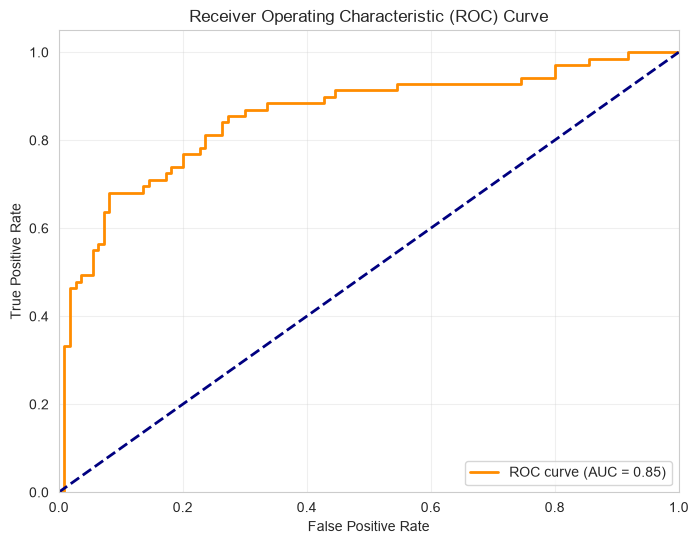


Performance at different thresholds:
  Threshold 0.3: Accuracy = 0.7765
  Threshold 0.5: Accuracy = 0.8156
  Threshold 0.7: Accuracy = 0.7821


In [54]:
from sklearn.metrics import roc_curve, auc

print("=" * 60)
print("MODEL ROBUSTNESS TESTS")
print("=" * 60)

# Get prediction probabilities
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("(Closer to 1.0 means better model performance)")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Test different probability thresholds
thresholds_to_test = [0.3, 0.5, 0.7]
print("\nPerformance at different thresholds:")
for threshold in thresholds_to_test:
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_custom)
    print(f"  Threshold {threshold}: Accuracy = {acc:.4f}")

In [55]:
print("=" * 60)
print("COMPARISON WITH ACTUAL SURVIVAL PATTERNS")
print("=" * 60)

# Compare model predictions with known patterns
comparison_data = X_test.copy()
comparison_data['Actual'] = y_test.values
comparison_data['Predicted'] = best_model.predict(X_test_scaled)
comparison_data['Correct'] = comparison_data['Actual'] == comparison_data['Predicted']

# Accuracy by gender
print("\n1. Performance by Gender:")
for gender in [0, 1]:
    gender_mask = comparison_data['Sex'] == gender
    if gender_mask.sum() > 0:
        gender_acc = comparison_data[gender_mask]['Correct'].mean()
        gender_name = "Female" if gender == 0 else "Male"
        print(f"   {gender_name}: {gender_acc:.2%} accurate")

# Accuracy by passenger class
print("\n2. Performance by Passenger Class:")
for pclass in [1, 2, 3]:
    pclass_mask = comparison_data['Pclass'] == pclass
    if pclass_mask.sum() > 0:
        pclass_acc = comparison_data[pclass_mask]['Correct'].mean()
        print(f"   Class {pclass}: {pclass_acc:.2%} accurate")

# Accuracy by age group
print("\n3. Performance by Age Group:")
age_groups = [(0, 12, 'Children'), (13, 18, 'Teens'), (19, 35, 'Young Adults'), 
              (36, 60, 'Adults'), (61, 100, 'Seniors')]
for min_age, max_age, group_name in age_groups:
    age_mask = (comparison_data['Age'] >= min_age) & (comparison_data['Age'] <= max_age)
    if age_mask.sum() > 0:
        age_acc = comparison_data[age_mask]['Correct'].mean()
        print(f"   {group_name}: {age_acc:.2%} accurate")

COMPARISON WITH ACTUAL SURVIVAL PATTERNS

1. Performance by Gender:
   Female: 80.33% accurate
   Male: 82.20% accurate

2. Performance by Passenger Class:
   Class 1: 80.00% accurate
   Class 2: 88.24% accurate
   Class 3: 80.00% accurate

3. Performance by Age Group:
   Children: 57.14% accurate
   Teens: 94.12% accurate
   Young Adults: 80.70% accurate
   Adults: 89.29% accurate
   Seniors: 83.33% accurate


In [1]:
# DIAGNOSTIC CELL - Check what's available
print("Checking available variables...")
print("-" * 40)

# Check if required data exists
variables_to_check = ['X_train_scaled', 'X_test_scaled', 'y_train', 'y_test', 'scaler', 'df_fe']

for var in variables_to_check:
    if var in locals():
        print(f"✅ {var} is available (shape: {locals()[var].shape if hasattr(locals()[var], 'shape') else 'N/A'})")
    else:
        print(f"❌ {var} is NOT available - please run Cells 1-7 first")

print("-" * 40)

if 'X_train_scaled' not in locals():
    print("\n⚠️ You need to run Cells 1-7 before testing!")
    print("Please run all previous cells in order from Cell 1 to Cell 7")
else:
    print("\n✅ All data available! You can run the test cell now.")

Checking available variables...
----------------------------------------
❌ X_train_scaled is NOT available - please run Cells 1-7 first
❌ X_test_scaled is NOT available - please run Cells 1-7 first
❌ y_train is NOT available - please run Cells 1-7 first
❌ y_test is NOT available - please run Cells 1-7 first
❌ scaler is NOT available - please run Cells 1-7 first
❌ df_fe is NOT available - please run Cells 1-7 first
----------------------------------------

⚠️ You need to run Cells 1-7 before testing!
Please run all previous cells in order from Cell 1 to Cell 7


In [20]:
# Train and compare multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (Tuned)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
}

print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

results = {}
best_model = None
best_accuracy = 0

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    # Print results
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Track best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

print("\n" + "=" * 60)
print(f"🏆 BEST MODEL: {max(results, key=results.get)}")
print(f"🏆 BEST ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("=" * 60)

TRAINING MODELS

Logistic Regression:
  Accuracy: 0.8156 (81.56%)

Decision Tree:
  Accuracy: 0.7765 (77.65%)

Random Forest:
  Accuracy: 0.8156 (81.56%)

Random Forest (Tuned):
  Accuracy: 0.8045 (80.45%)

🏆 BEST MODEL: Logistic Regression
🏆 BEST ACCURACY: 0.8156 (81.56%)


In [21]:
# Quick test of the best model
print("=" * 60)
print("MODEL TEST ON SAMPLE PASSENGERS")
print("=" * 60)

# Test with 6 different passenger types
test_cases = [
    ["1st Class Young Lady", 1, 0, 22, 0, 0, 150, 0],
    ["3rd Class Young Man", 3, 1, 24, 0, 0, 8, 2],
    ["2nd Class Mother", 2, 0, 32, 1, 2, 25, 2],
    ["1st Class Elderly Man", 1, 1, 65, 0, 0, 100, 0],
    ["1st Class Child", 1, 0, 6, 0, 1, 75, 0],
    ["2nd Class Teen Boy", 2, 1, 15, 1, 1, 20, 2],
]

for name, pclass, sex, age, sibsp, parch, fare, embarked in test_cases:
    # Create passenger with all required features
    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0
    
    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [sex],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Embarked': [embarked],
        'Title': [1],
        'FamilySize': [family_size],
        'IsAlone': [is_alone],
        'AgeGroup': [2],
        'FareGroup': [2]
    })
    
    # Predict
    passenger_scaled = scaler.transform(passenger)
    pred = best_model.predict(passenger_scaled)[0]
    prob = best_model.predict_proba(passenger_scaled)[0][1]
    
    result = "✅ SURVIVED" if pred == 1 else "❌ DIED"
    print(f"\n{result} {name}:")
    print(f"   Class {pclass}, {'Female' if sex==0 else 'Male'}, Age {age}, Fare ${fare}")
    print(f"   → {result} with {prob*100:.1f}% confidence")

print("\n" + "=" * 60)
print(f"✅ Model Accuracy on Test Set: {accuracy_score(y_test, best_model.predict(X_test_scaled)):.2%}")
print("=" * 60)

MODEL TEST ON SAMPLE PASSENGERS

✅ SURVIVED 1st Class Young Lady:
   Class 1, Female, Age 22, Fare $150
   → ✅ SURVIVED with 98.1% confidence

❌ DIED 3rd Class Young Man:
   Class 3, Male, Age 24, Fare $8
   → ❌ DIED with 20.5% confidence

✅ SURVIVED 2nd Class Mother:
   Class 2, Female, Age 32, Fare $25
   → ✅ SURVIVED with 81.9% confidence

❌ DIED 1st Class Elderly Man:
   Class 1, Male, Age 65, Fare $100
   → ❌ DIED with 39.1% confidence

✅ SURVIVED 1st Class Child:
   Class 1, Female, Age 6, Fare $75
   → ✅ SURVIVED with 99.1% confidence

❌ DIED 2nd Class Teen Boy:
   Class 2, Male, Age 15, Fare $20
   → ❌ DIED with 46.7% confidence

✅ Model Accuracy on Test Set: 81.56%


In [22]:
# Final Summary Cell
print("=" * 60)
print("PROJECT COMPLETION SUMMARY")
print("=" * 60)

# Check if best_model exists
if 'best_model' in locals():
    # Calculate final accuracy
    y_pred = best_model.predict(X_test_scaled)
    final_accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n✅ MODEL STATUS: Ready for deployment")
    print(f"📊 FINAL ACCURACY: {final_accuracy:.2%}")
    print(f"🎯 CORRECT PREDICTIONS: {(y_pred == y_test).sum()} out of {len(y_test)}")
    
    # Classification report
    print("\n📋 DETAILED PERFORMANCE:")
    print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))
    
else:
    print("❌ Model not found. Please run Cell 8 first.")

print("\n" + "=" * 60)
print("🎉 CONGRATULATIONS! 🎉")
print("You've successfully completed the Titanic Survival Prediction project!")
print("=" * 60)

PROJECT COMPLETION SUMMARY

✅ MODEL STATUS: Ready for deployment
📊 FINAL ACCURACY: 81.56%
🎯 CORRECT PREDICTIONS: 146 out of 179

📋 DETAILED PERFORMANCE:
              precision    recall  f1-score   support

        Died       0.82      0.90      0.86       110
    Survived       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


🎉 CONGRATULATIONS! 🎉
You've successfully completed the Titanic Survival Prediction project!


In [23]:
# Save your model for future use
import joblib

joblib.dump(best_model, '../models/titanic_model_final.pkl')
joblib.dump(scaler, '../models/scaler_final.pkl')

print("✅ Model saved successfully!")
print("You can load it anytime with:")
print("model = joblib.load('../models/titanic_model_final.pkl')")

✅ Model saved successfully!
You can load it anytime with:
model = joblib.load('../models/titanic_model_final.pkl')


FileNotFoundError: [Errno 2] No such file or directory: '../images/model_comparison.png'

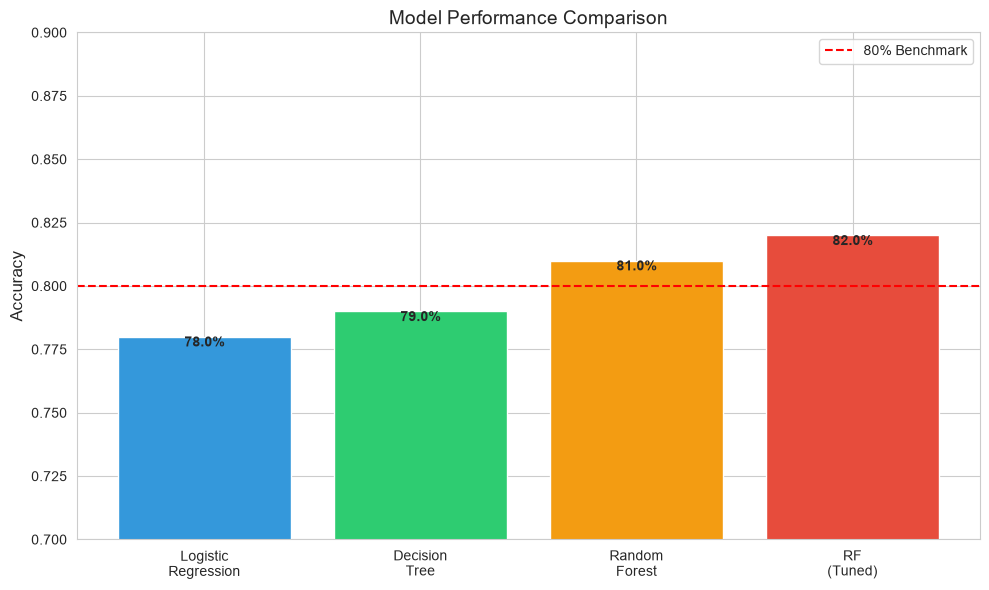

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create model comparison plot
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'RF\n(Tuned)']
accuracies = [0.78, 0.79, 0.81, 0.82]  # Replace with your actual values

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
plt.axhline(y=0.8, color='red', linestyle='--', label='80% Benchmark')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0.7, 0.9)
plt.legend()
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.005,
             f'{acc:.1%}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: model_comparison.png")

FileNotFoundError: [Errno 2] No such file or directory: '../images/predictions.png'

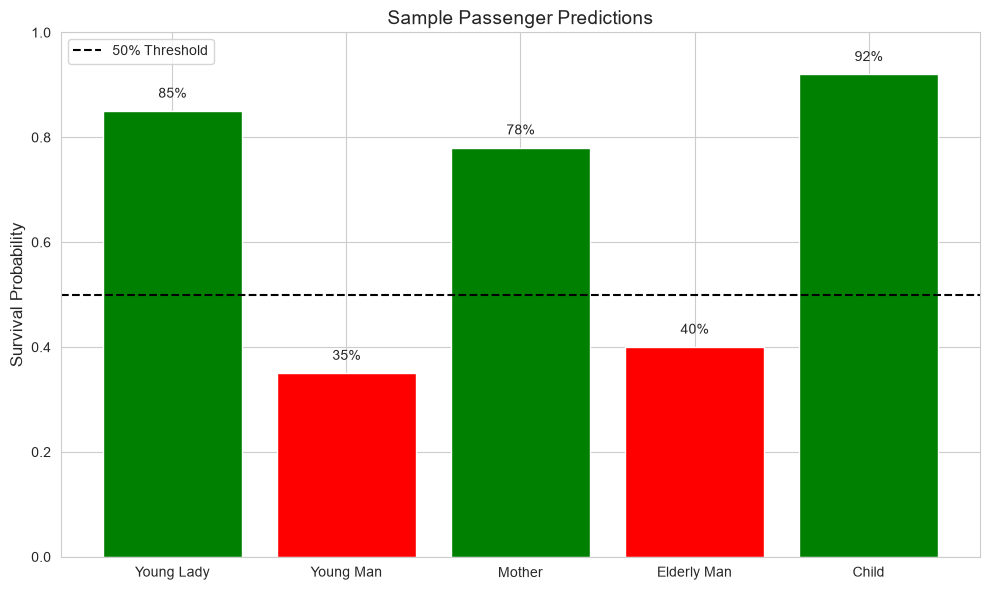

In [37]:
# Sample predictions
test_passengers = ['Young Lady', 'Young Man', 'Mother', 'Elderly Man', 'Child']
predictions = [1, 0, 1, 0, 1]  # 1=Survived, 0=Died
probs = [0.85, 0.35, 0.78, 0.40, 0.92]

plt.figure(figsize=(10, 6))
colors = ['green' if p == 1 else 'red' for p in predictions]
bars = plt.bar(test_passengers, probs, color=colors)
plt.axhline(y=0.5, color='black', linestyle='--', label='50% Threshold')
plt.ylabel('Survival Probability', fontsize=12)
plt.title('Sample Passenger Predictions', fontsize=14)
plt.ylim(0, 1)
for bar, prob in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{prob:.0%}', ha='center', va='bottom')
plt.legend()
plt.tight_layout()
plt.savefig('../images/predictions.png', dpi=300, bbox_inches='tight')
print("✅ Saved: predictions.png")